In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../../style_Matplotlib_charts.mplstyle")
from sklearn.linear_model import LinearRegression
import pickle
from sklearn.preprocessing import PolynomialFeatures

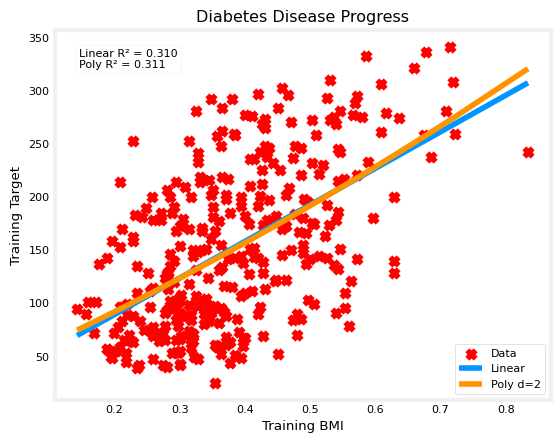

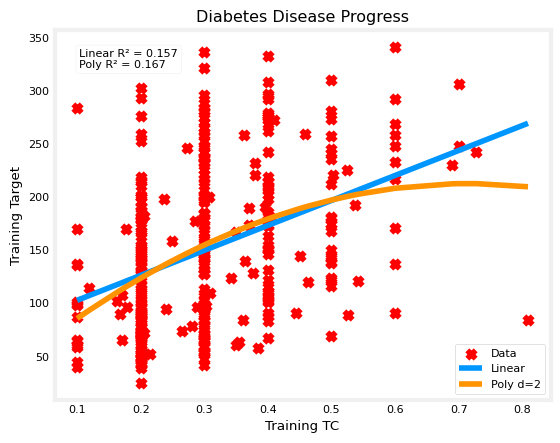

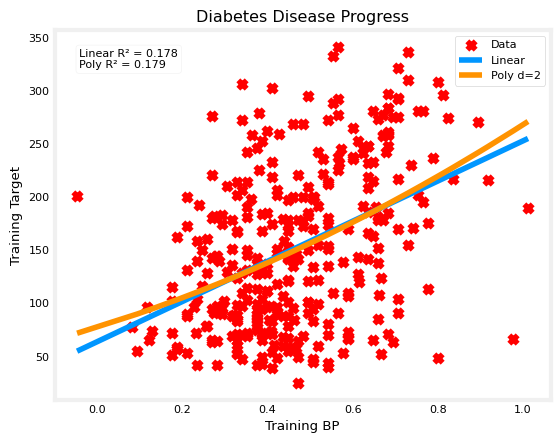

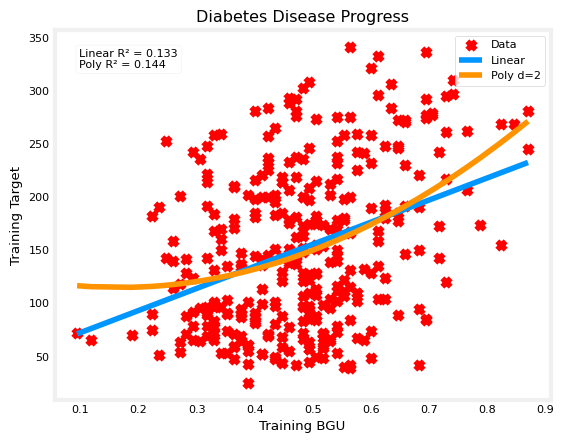

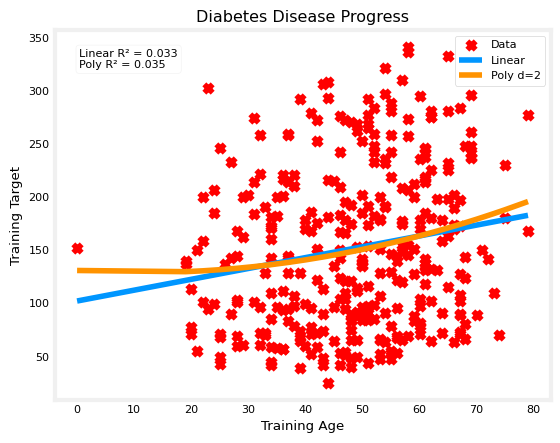

In [2]:
features = ['BMI', 'TC', 'BP', 'BGU', 'Age']
degree = 2

training_data = pd.read_csv("2.3.2.training_data.csv")
for i in features:
    x_name = i
    y_name = "Target"
    x = np.array(training_data[x_name]).reshape(-1, 1)
    y = np.array(training_data[y_name])

    # Linear model
    linear_model = LinearRegression()
    linear_model.fit(x, y)
    y_pred_linear = linear_model.predict(x)
    r2_linear = linear_model.score(x, y)

    # Polynomial model
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_poly = poly.fit_transform(x)
    poly_model = LinearRegression()
    poly_model.fit(x_poly, y)
    y_pred_poly = poly_model.predict(x_poly)
    r2_poly = poly_model.score(x_poly, y)

    # Sort x for smooth lines
    sort_idx = np.argsort(x[:, 0])
    x_sorted = x[sort_idx]
    y_pred_linear_sorted = y_pred_linear[sort_idx]
    y_pred_poly_sorted = y_pred_poly[sort_idx]

    plt.scatter(x, y, marker="x", c="r", label="Data")
    plt.plot(x_sorted, y_pred_linear_sorted, label=f"Linear")
    plt.plot(x_sorted, y_pred_poly_sorted, label=f"Poly d={degree}")

    plt.title("Diabetes Disease Progress")
    plt.ylabel(f"Training {training_data[y_name].name}")
    plt.xlabel(f"Training {training_data[x_name].name}")

    plt.text(
        0.05, 0.95,
        f"Linear R² = {r2_linear:.3f}\nPoly R² = {r2_poly:.3f}",
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.show()